In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#import seaborn as sns
import math
#from plotnine import *
#import scvi
import os
#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
%matplotlib inline
sc.settings.verbosity = 0




/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline

sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(14,14))


# scRNA - CORE DATA

# PAN-DISEASE ATLAS

In [3]:
import scanpy as sc
#PATH = '/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_data/model_scanvi5_atlasv2_nojunk_5861/adata_all_scvi5.h5ad.withjunk'

#PATH='adata_all_scvi5.h5ad.withjunk.h5ad'
#cp '/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_data/model_scanvi5_atlasv2_nojunk_5861/adata_all_scvi5.h5ad.withjunk.h5ad' /nfs/team298/ls34/adult_skin/final_adatas/adata_pandisease_eos.h5ad
#PATH =  "/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_output/adata_atlas_incxenium_v5.h5ad"
PATH='/nfs/team298/ls34/adult_skin/final_adatas/adata_pandisease_eos.h5ad'
adata=sc.read_h5ad(PATH)

/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
adata

AnnData object with n_obs × n_vars = 3162521 × 36610
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'n_genes', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl5_annotation_new', 'lvl5_annotation_new2', 'lvl5_annotation_new3', 'lvl5_annotation_new_archive', 'lvl5_annotation_new_preoprhan', 'lvl5_annotation_new10', 'lvl5_annotation_new11', 'test', 'test_n', 'lvl5_annotation_new12', 'lvl5_annotation_new13', 'lvl4_annotation', 'lvl0', 'temp', 't', 'leiden_res0.1', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary', 'lvl1_new', 'orig.ide

In [5]:
import pickle

try:
    file_path = "/nfs/team298/ls34/dicts/color_for_adult_skin2.pkl"
    with open/(file_path, "rb") as f:
        colors = pickle.load(f)
except:
    !wget "https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl" \
         -O color_for_adult_skin2.pkl
    file_path = "./color_for_adult_skin2.pkl"
    with open(file_path, "rb") as f:
        colors = pickle.load(f)
colors= colors | {'New/unlabelled/excluded': "#C8C8C8",
                  'New/unlabelled/unspecific':  "#C8C8C8",
                  'F1: Superficial': '#ffef5a',
    'F2/3: Perivascular': '#364f99',
    'F2: Universal': '#91bae2',
    'F3: FRC-like': '#c6508f',
    'F4: DP_HHIP+': '#c9efb4',
    'F4: DS_DPEP1+': '#3d6f3b',
    'F4: TNN+COCH+': '#00f273',
    'F5: NGFR+': '#8981a7',
    'F5: RAMP1+': '#4b2657',
     'F6: Inflammatory myofibroblast': "#75fbfd",
     'F7: Myofibroblast': "#2f6565",
       'F8: Fascia-like myofibroblast':"#EFA093", #'#dd7465',
 'F_Fascia': "#00004D",
                     "Th2": "#2A6072",      # Dark Blue (classic, strong contrast)
    "Tfh-like": "#AAA9A9",  # Neon Blue (bright, electric tone)
    "Th17": "#FFB3B3",
                  "adipocyte": '#B8860B'

     #   "TRM_IL13+": "#7D93C7"
    
                               } 
print(f"Loaded {len(colors)} colour entries")
colors2 = {'Sweat gland_clear': '#8AEAEA',
 'Sweat gland_dark': '#006D6D',

 'LE1': '#FFFF2B',

 'MacTREM2hi': '#E9E2F0',
 'LE2': '#D5D500',
 'Scar_VE/Peri': '#FF9B9B',
 'Mac2_MMP19hi': '#DDD3E9',
 'Mast cell_Active_ABCC4hi': '#FFB14D',
 'Mac2_HRH1+': '#D2C4E2',
 'KC3*': '#758BCC',
 'KC1/2_cycling': '#e0c5d2',
 'KC4/5': '#272c5f',
 'KC4*': '#9FC2CD',
 'KC_HFSC': '#D600FF',
 'T_CD4ex': '#FFE8B3',
            'ASIC2+ Mechanoreceptor': '#F1F1F1',
            'lowq': '#F1F1F1',
                       'new': '#F1F1F8',


 'ASIC2+ Mechanoreceptor2': '#F1F1F1',
 'Tfh-like2': '#AAA9A9',
 'ASIC1_4_KIF5C+': '#6F6F6F',
 'TRM_ex': '#FFF8E1',
 'Mast cell_prolif': '#FFA64D',
 'Th17/IFNGhi': '#FFA000',
 'Tc1_GIMAPhi': '#FFD06A',
 'KC_HF: ORS_KLK8+_SRGN+': '#E8FFF0',
 'ASIC2+ Mechanoreceptor1': '#D9D9D9',
 'Tfh-like1': '#AAB7C3',
 'Th_IFNGhi': '#FFB00A',
 'T DC Doublet': '#B38066',
 'SCC_KC': '#7B9299',
 'Melanoma': '#4E3323',
 'BCC+SCC_KC': '#576166',
 'Merkel_KC': '#FFE5E5'}
colors=colors|colors2
COLORS = {
    "ILC3+CCL1+PTGDS+": "#FF2F92",        # neon pink
    "ILC1_Prolif": "#FFD800",             # bright yellow
    "Tγδ": "#8B5A2B",                     # brown
    "CD4+_Prolif": "#C2B280",             # dark beige
    "CD4_IL13+ (was TRM_IL17+)": "#87CEEB",# sky blue
    "Th(ribosomal)": "#F2E6D8",            # very pale beige
    "Tc3_IFNGhi_CCL3+": "#E6D3B1",         # neon-ish beige
    "Tc1_BACH2+": "#E39A2E",               # orange beige
    "Th_PPARGhi_SLC10A1+TNFhi": "#9BB7D4", # bluish beige
    "Tc2_GZMH+": "#F28C28",                # orange
    "Tc3_IFNGhi_exhausted": "#FFE5C4",     # very pale orange
    "CD4_Tex_GZMK+IL10+PDCD1+": "#EFE2CF", # very pale beige
    "ILC3_Early": "#F6B7C6",               # pale pink
    "Th17_CCL20+ZBTB16+LAYN+": "#6FBF73",  # greenish
    "Th1_KLRG1+": "#D8C4A8",               # beige
    "Tc2_GZMH+TOX+": "#F3E6D3",             # very pale beige (distinct)
    "TRM_IL13+_2": "#3A6EA5",               # blue
    "Th1_KLRG1+GZMK+A2M+LYAR+": "#FFF2A6",  # pale yellow
    "Th17/Th1__IFNG+CXCL13+SOX5+": "#FFCC00", # bright yellow (distinct hue)
    "Th17_IL17F+": "#C23B22",               # reddish
    "ILC3_Prolif": "#B8A17D",               # dark beige
    "Tc1_BACH2+_TOXhi": "#9E8B6B",          # darker beige
    "TRM_exhausted": "#E6F0FA",             # very very pale blue
    "Th17_LAG3lo_IL23RhiBLK+": "#B22222",   # deep reddish
    "CD8+_naive": "#F5EDDF",                # very pale beige
    "TRM_IL13+_3_CD9+KRT7+": "#1E90FF",     # neon blue
    "TRM_IL13+_1": "#0B3C5D",               # dark blue
    "CD4 (was TRM_IL17+)": "#F9E1E1",       # very very pale red
    "Tfh-like1_ICA1+": "#9E9E9E",            # grey
    "CD4_IL17+ (was TRM_IL17+)": "#800020", # burgundy
    "TRM_CD4+_IL17+ITGA1+": "#F4A6A6",      # pastel red
    "TRM2_exhausted": "#EDF4FB",            # very pale blue (distinct)
    "TRM_CD4/CD8_mixed": "#A89272",         # dark beige
    "Th_PPARGhi_HLF+": "#8C7A5E",            # dark beige (darker)
    "CD8+_naive_exhausted_HAVCR2+": "#E8C2B3", # pinkish beige
    "Th2/mac": "#000000",                   # black
    
        "CD8+_Prolif": "#C2B280",          # dark beige
    "CD4_LOWQ(was TRM_IL17+)": "#D3D3D3",  # light grey
    "Th2_SLC10A1+TNFhi": "#7EC8E3",     # sky blue (clear, not pastel mush)
    "Th17_IL17A+IL17F+": "#4CAF50",     # grass green
    "Th17_IL17A+IL23R+": "#A5D6A7",     # pale green
    "T_Prolif_mixed": "#1B9E3C",        # intense green (distinct from Th17)
    "Th2_SATB1+PRDX2+": "#EEEEEE",      # very pale grey (still visible on white)
     "lowq_ithink": "#4D4D4D",
    "lowq_mac": "#595959",
    "Pericyte1doublet": "#666666",
    "Tlowq": "#737373",
    "KC2/lowqmaybe": "#808080",
    "KC2_lowq": "#8C8C8C",
    "lowq_ilc": "#999999",
    "ILC_Stress": "#A6A6A6",
    "Mac_Prolif": "#B3B3B3",
    "Tfh-like_Ex": "#BFBFBF",
    "Th1_IFNG+": "#CCCCCC",
    "Th17_ZBTB16+": "#D9D9D9",
    "Tc0 i think": "#E6E6E6",
    "KC_HF: ORS_CLEC2A+KLK8+": "#F0F0F0",
    
     "KC2_stress": "#4D4D4D",
        "Lowq": "#999999",

}
colors=colors|COLORS


import pickle
from pathlib import Path

out_path = Path("/nfs/team298/ls34/dicts/color_for_adult_skin3.pkl")

with open(out_path, "wb") as f:
    pickle.dump(colors, f, protocol=pickle.HIGHEST_PROTOCOL)
    









--2026-05-31 18:51:44--  https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4369 (4.3K) [application/octet-stream]
Saving to: ‘color_for_adult_skin2.pkl’

color_for_adult_ski 100%[===================>]   4.27K  --.-KB/s    in 0s      

2026-05-31 18:51:44 (117 MB/s) - ‘color_for_adult_skin2.pkl’ saved [4369/4369]

Loaded 200 colour entries


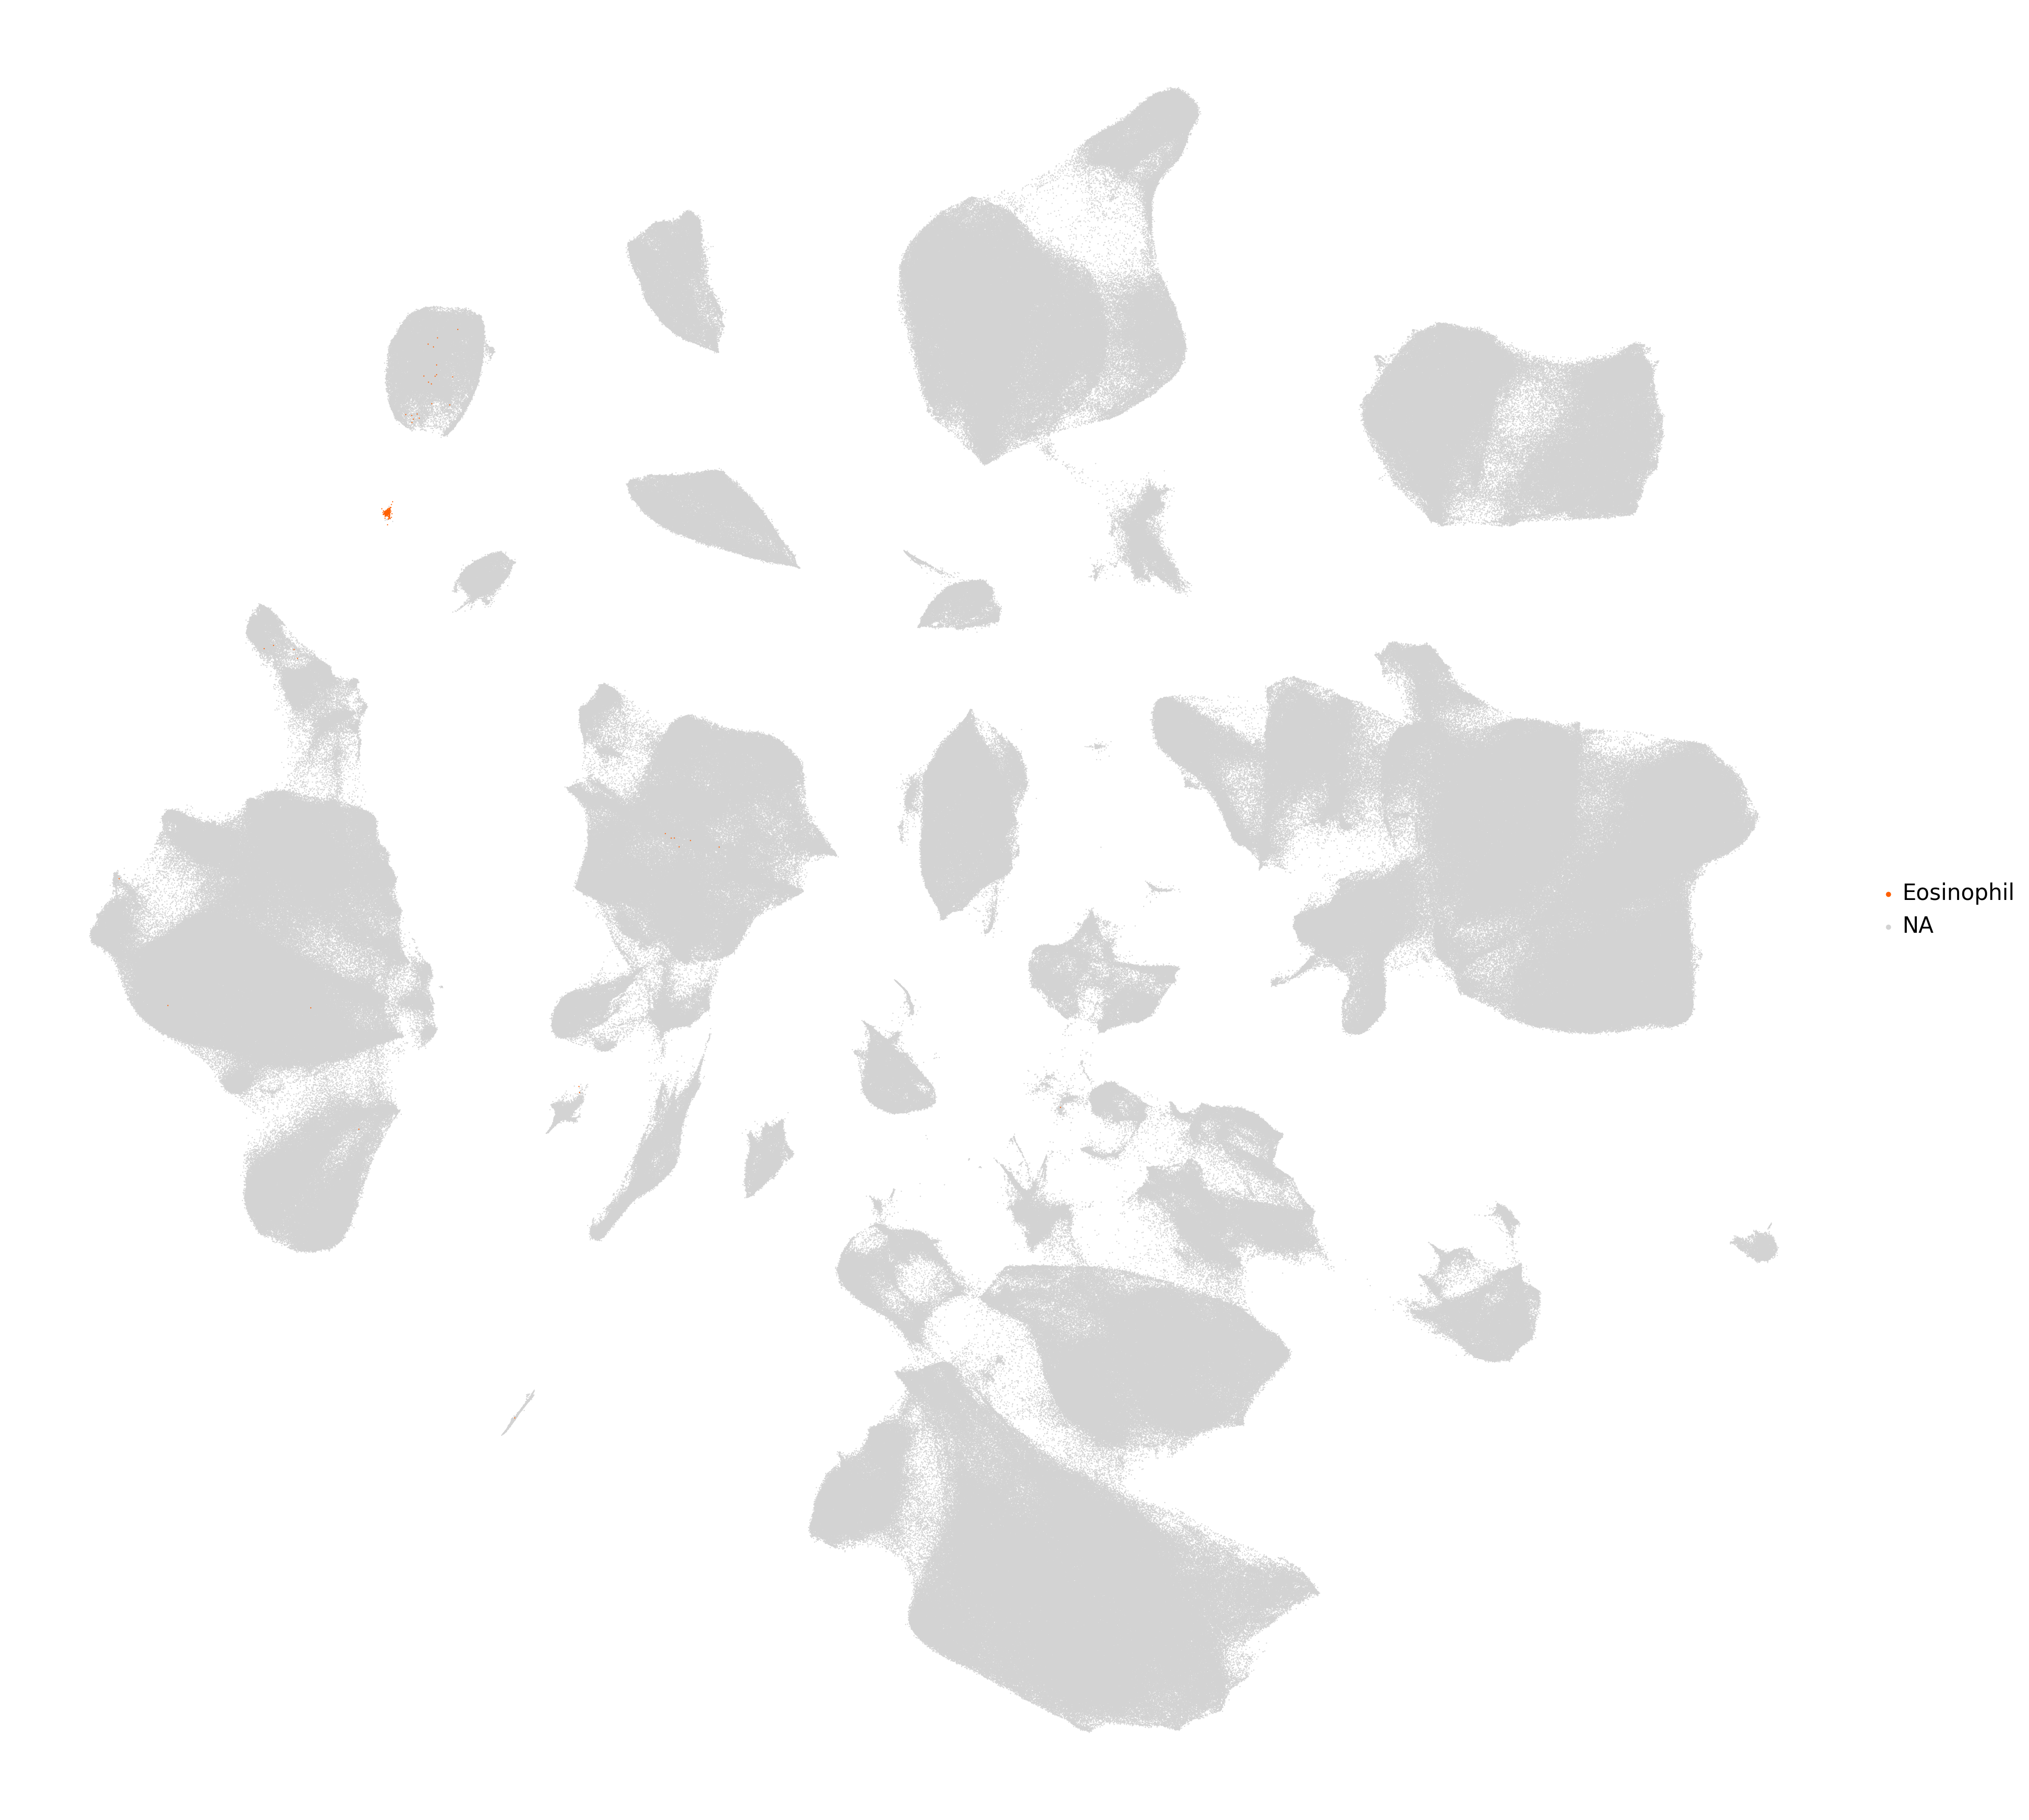

In [6]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(45,45))

sc.pl.umap(
    adata,
    color='final4',
    show=True,
    frameon=False,
    #legend_loc= "on data",
    legend_fontsize=30,
    s=10,
    title='',
    legend_fontoutline=2,
    vmax=60,
    palette=colors,
    groups="Eosinophil",
    save="eosinophil_pandisease_umapall.pdf"
                   
   # save="supplementary_integration.pdf"
)



In [7]:
1

1

In [8]:
adata_i=adata[(adata.obs["final4"]=="Eosinophil")|
              (adata.obs["final4"]=="Mast cell")|
                (adata.obs["final4"]=="Neutrophil")
             
             
             ].copy()


/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
sc.pp.normalize_total(adata_i, target_sum=1e4)
sc.pp.log1p(adata_i)



/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


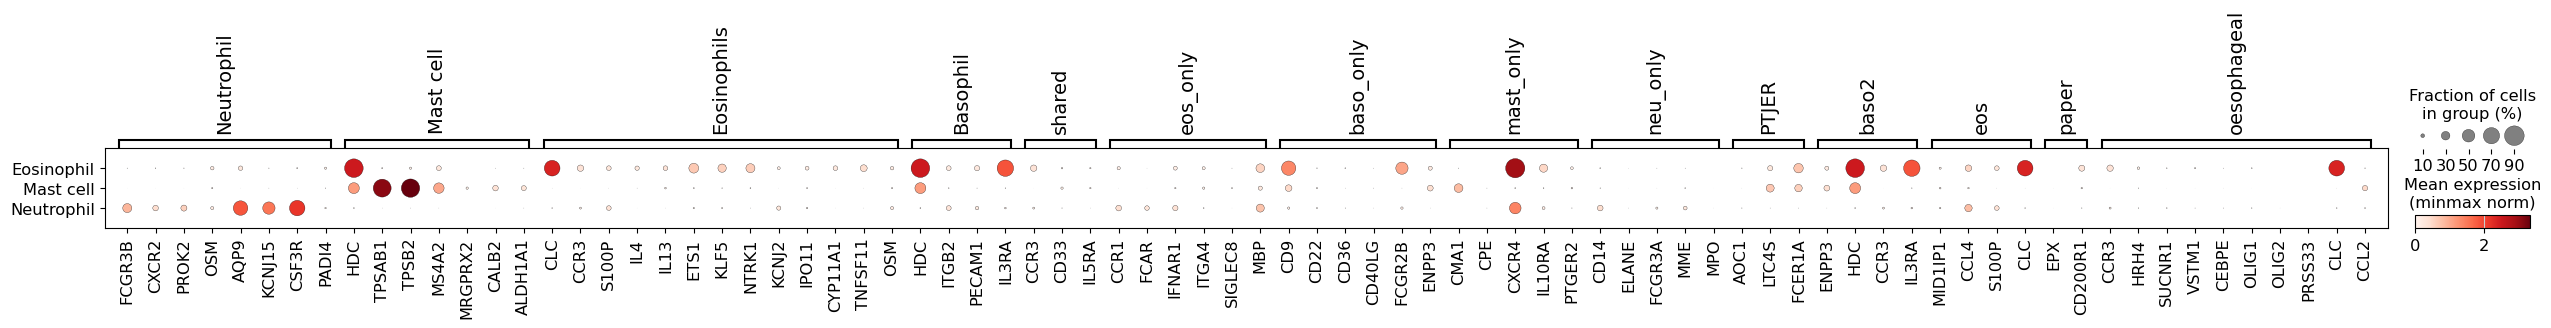

In [10]:
PLOT = { 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM"
                           ],
        "Basophil": [#"MCPT8", 
            "HDC",
                    "ITGB2", "PECAM1", "IL3RA"
                    ],
           "shared": ["CCR3", "CD33", "IL5RA"],
    "eos_only": ["CCR1", "FCAR", "IFNAR1", "ITGA4", "SIGLEC8", "MBP"],
    "baso_only": ["CD9", "CD22", "CD36", "CD40LG", "FCGR2B",
                 "ENPP3"
                 ],
    "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    "PTJER": ["AOC1", "LTC4S", "FCER1A"],
      "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
        "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
        "paper": ["EPX",  "CD200R1"],
        "oesophageal": [
    "CCR3",
    "HRH4",
    "SUCNR1",
    "VSTM1",
    "CEBPE",
    "OLIG1",
    "OLIG2",
    "PRSS33",
    "CLC", "CCL2"
]
            }


sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="final4",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 


In [12]:
PRENATAL_GENES = {"BASOPHIL ONLY": ["PADI4", "NCF2", "TRMP6", "ITGB7", "CCR3",
                                   "NLRC5", "VSTM1"
                                   ],
                    "BASOPHIL MOSTLY": ["NCF1", "IL3RA", "S100P",
                                       "CR1", "MYO1F", "SULF2", 
                                       ],
                  "EOS": ["CALCRL", "IL13", "CXCL2", "CEMIP2", "HELLS", "CREG1", 
                         "IL4", "CD7", "BCL21L2"
                         ],
                  "ME":["IL3RA", "IL5RA"]
                         
    
}
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PRENATAL_GENES,
              groupby="final4",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 


/software/cellgen/team298/ls34/ccc_liana/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


KeyError: "Could not find keys '[np.str_('BCL21L2'), np.str_('TRMP6')]' in columns of `adata.obs` or in adata.var_names."

In [ ]:
genes_dict = {
    "PRENATALSKIN": ["PRG2", "IL5RA", "IL3RA"],
    "Gonzalo": [
    "CPA3",
    "HDC",
    "CLC",
    "FCER1A",
    "IL3RA",
    "SLC45A3",
    "IL5RA",
    "HRH4",
    "PRG2",
    "FUT4",
    "CD34",
],
}

sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              genes_dict,
              groupby="final4",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 


In [ ]:
# adata.obs["xeniummap"] = adata.obs["final17"].where(
#     adata.obs["tech"] == "scrna",  # keep final17 only if tech is scrna
#     other="new"                     # otherwise set "new"
# )

# # Optional: make categorical
# adata.obs["xeniummap"] = adata.obs["xeniummap"].astype("category")

In [ ]:
1

In [ ]:
adata_i.obs.dataset_id.value_counts()

In [ ]:
adata_i=adata[adata.obs["final4"]=="Eosinophil"].copy()


In [ ]:
sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(45,45))


In [ ]:
import matplotlib.pyplot as plt

counts = (
    adata_i.obs["Patient_status"]
    .value_counts()
    .head(5)
    .sort_values(ascending=False)
)

plt.figure(figsize=(2.8, 2.0))

plt.bar(
    counts.index,
    counts.values,
    width=0.55,
    color="#F4B183",
    edgecolor="black",
    linewidth=0.5
)

ax = plt.gca()

# remove background grid explicitly
ax.grid(False)

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=90)

# horizontal ylabel
plt.ylabel("Eos\ncount", rotation=0, labelpad=25)

plt.xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
sc.pp.neighbors(adata_i, use_rep = 'X_scanvi', metric = "euclidean", 
                n_neighbors=20,key_added="neighbor_20")

print("neighbours done")
print("start umap")
sc.tl.umap(adata_i, min_dist=0.1, neighbors_key = "neighbor_20" ) 
sc.tl.leiden(adata_i, resolution=2, key_added='leiden_res2', neighbors_key="neighbor_20")

sc.pl.umap(
    adata_i,
    color=[
      'leiden_res0.3',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(10,10))

sc.pl.umap(
    adata_i,
    color=[
      'leiden_res2',
    ],
    legend_loc="on data",
    s=300, 
    legend_fontoutline=2,
    legend_fontsize=30
)

In [ ]:
sc.tl.leiden(adata_i, resolution=1, key_added='leiden_res1', neighbors_key="neighbor_20")

sc.pl.umap(
    adata_i,
    color=[
      'leiden_res1',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:

sc.pp.normalize_total(adata_i, target_sum=1e4)
sc.pp.log1p(adata_i)

In [ ]:
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(10,10))

PLOT = {   "Eosinophils": [  "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13", "ALOX5",
    "ETS1",
   # "KLF5",
   # "NTRK1",
   # "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM", "IKZF1",
    "CD69",
     
    "CORO1A",
   
    "NR4A1",
   
    "IL3RA","MBP"
                    
    
    
    
#     "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
#                             "S100P", "C5AR1",    "CYP11A1", 
#                              "IL4",
#     "IL13",
#     "NTRK1",
#     "KCNJ2",
#     "IPO11",

#     "TNFSF11",
#     "OSM"
                           ],
        "Basophil": [#"MCPT8", 
     "CD22", "CD36",# "CD40LG", "FCGR2B",
               #  "ENPP3"
            
             'CD40LG', 'FCGR1B', 'FCGR3A', 'FCGR2B', 'CXCR1', 'CXCR2'
            
                 ],
    # "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    # "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    # "PTJER": ["AOC1", "LTC4S", "FCER1A"],
    #   "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
    #     "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
    #     "paper": ["EPX",  "CD200R1"]
            }
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res2",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(log1p norm)",
              vmax=3,
             swap_axes=True,
             #   dot_max=.3,
             )

 

In [ ]:
# PLOT = {   "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
#                             "S100P", "C5AR1",    "CYP11A1", 
#                              "IL4",
#     "IL13",
#     "ETS1",
#     "KLF5",
#     "NTRK1",
#     "KCNJ2",
#     "IPO11",

#     "TNFSF11",
#     "OSM"
#                            ],
#         "Basophil": [#"MCPT8", 
#      "CD22", "CD36",# "CD40LG", "FCGR2B",
#                #  "ENPP3"
#                  ],
#     # "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
#     # "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
#     # "PTJER": ["AOC1", "LTC4S", "FCER1A"],
#     #   "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
#     #     "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
#     #     "paper": ["EPX",  "CD200R1"]
#             }
# sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
#               PLOT,
#               groupby="final4",
#               dendrogram=False, 
#                # standard_scale="var",
#               colorbar_title="Mean expression\n(minmax norm)",
#              # swap_axes=True,
#              #   dot_max=.3,
#              )

 

In [ ]:
PLOT = { 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM"
                           ],
        "Basophil": [#"MCPT8", 
            "HDC",
                    "ITGB2", "PECAM1", "IL3RA"
                    ],
           "shared": ["CCR3", "CD33", "IL5RA"],
    "eos_only": ["CCR1", "FCAR", "IFNAR1", "ITGA4", "SIGLEC8", "MBP"],
    "baso_only": ["CD9", "CD22", "CD36", "CD40LG", "FCGR2B",
                 "ENPP3"
                 ],
    "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    "PTJER": ["AOC1", "LTC4S", "FCER1A"],
      "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
        "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
        "paper": ["EPX",  "CD200R1"]
            }
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res0.3",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 

In [ ]:
RENAME = {"1": "Basophil",
          "0": "Eosinophil",
          "2": "Eosinophil",
          "3": "Eosinophil",
         
         }
adata.obs["tmp"] = adata.obs["leiden_res1"].map(RENAME)

In [ ]:
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res0.3",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

In [ ]:
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res1",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

In [ ]:
adata_i.obs.Patient_status.value_counts()

In [ ]:
sc.tl.leiden(adata_i, resolution=2, key_added='leiden_res2', neighbors_key="neighbor_20")

sc.pl.umap(
    adata_i,
    color=[
      'leiden_res0.3',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res2",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

In [ ]:
adata_i[adata_i.obs["leiden_res2"]=="13"].obs["Patient_status"].value_counts()

In [ ]:
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="tmp",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

In [ ]:
sc.pl.umap(
    adata,
    color=[
      'lvl5_annotation',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [ ]:
genes_dict = {
    "eosinophil_specific": ["P2RY2", "NCF2", "CAT", "CD300LF"],
    "other_set": ["PTGER3", "LDLR", "AKAP12", "NTRK1", "ENPP3", "ATP10D", "GCSAML", "SLC45A3"]
}

sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              genes_dict,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 

In [ ]:
# CATEGORY="lvl5_annotation"

# try:
#     adata.obs["trm"] = adata.obs[CATEGORY].astype(str) + "__" +  adata.obs["Site_status"].astype(str)
#     #CATEGORY="lvl3_annotation_patient_status"
#     adata.obs["trm"].value_counts()
# except:
#     1

In [ ]:
import gc
gc.collect()

In [ ]:
# KEEP

In [ ]:
# KEEP = adata_5k.obs['lvl5_annotation'].unique().tolist()
# KEEP=[x for x in KEEP if "prolif" not in x.lower()]
# adata=adata[adata.obs['lvl5_annotation'].isin(KEEP)].copy()

In [ ]:
# adata.obs["Patient_status"].value_counts()

In [ ]:
# adata_5k.obs["Site_status"].value_counts()

In [ ]:
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )



# sc.pl.dotplot(adata_5k[adata_5k.obs["Site_status"]=="Lesional"], 
#               remove_markers(["MCPT8", "HDC"],
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=.3,
#               colorbar_title="Mean expression\n(minmax norm)",
#                             swap_axes=True,

#              )

 

In [ ]:
markers = {
 
}
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              markers,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )


In [ ]:
stopaa

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



In [ ]:
CATEGORY="scanvi_pred_fine_curated"
import pandas as pd
#sc.tl.rank_genes_groups(adata, CATEGORY, method='wilcoxon', key_added="de_leiden");
df22 = pd.DataFrame(adata.uns['de_leiden']['names'])
for i,x in enumerate(df22.columns):
    print(i, x)

In [ ]:
select_population = list(df22.columns)[0
                                       
                                       
                                      ]  # JAW
print(select_population)
genes0 = df22[select_population][:50]
genes1 = df22[select_population][50:100]
genes2 = df22[select_population][100:150]
genes3 = df22[select_population][150:200]


# sc.pl.dotplot(
#     adata,
#     genes0,
#     groupby=CATEGORY,
#     standard_scale="var",
#     dendrogram=False, 
# )
# sc.pl.dotplot(
#     adata,
#     genes1,
#     groupby=CATEGORY,
#    standard_scale="var",
#     dendrogram=False, 
# ) 
# sc.pl.dotplot(
#     adata,
#     genes2,
#     groupby=CATEGORY,
#    standard_scale="var",
#     dendrogram=False, 
# ) 




In [ ]:
AREG, CLC, CD9, RFLNB, MAX, HSH2D, NDUFV2, NLK, FCGR2B

In [ ]:
sc.pl.dotplot(adata_5k[adata_5k.obs["Site_status"]=="3D_Lesional_baseline"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
             aa   standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
adata_i.obs.tech.value_counts()

In [ ]:
1

In [ ]:
sc.pp.normalize_total(adata_i, target_sum=1e4)
sc.pp.log1p(adata_i)



In [ ]:






sc.pl.dotplot(adata_i[adata_i.obs["tech"]!="xenium"], 
              remove_markers(["CCL1", "CCR8", "IL13"]),
              groupby="Site_status",
              dendrogram=False, 
                #standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
                dot_max=.3,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
            # save="supp1d_ccl1expression_scrna.pdf"
             )

sc.pl.dotplot(adata_i[adata_i.obs["tech"]=="xenium"], 
              ["CCL1", "CCR8", "IL13"],
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
ALL =   {'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1',
                                
                                     'CTSH',
  'VDR',
                                   ],

 'Th2': ['IL13', "CCL1", 'NBAS',# 'CCL17',
         'AREG', 'IL9R',# 'PDLIM4', 
         #'CCR8',
        # 'ZBTB16', 'KLRC4', 'ADGRG1',
         'RGS9',
        "SATB1", "PRDX2", "IL5",
         'IL22', 
        ]}

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST

In [ ]:
# sc.pl.dotplot(adata, 
#               remove_markers(["IL4", "IL13"]),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=.7,
#               colorbar_title="Mean expression\n(minmax norm)",
#               swap_axes=True,
#              #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
#             # save="supp1d_ccl1expression_scrna.pdf"
#              )

# sc.pl.dotplot(adata_5k, 
#               remove_markers(["IL4", "IL13"]),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=.3,
#               colorbar_title="Mean expression\n(minmax norm)",
#                             swap_axes=True,
# #save='supp1d_ccl1expression_xenium.pdf'
#              #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
#              # save="supp1d_tdotplot.pdf"
#              )

sc.pl.dotplot(adata_i[adata_i.obs["tech"]!="xenium"], 
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
                #standard_scale="var",
              colorbar_title="Mean expression\n(log1p norm)",
            #  swap_axes=True,
                dot_max=.3,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
            # save="supp1d_ccl1expression_scrna.pdf"
             )
sc.pl.dotplot(adata_i[adata_i.obs["tech"]=="xenium"], 
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(log1p norm)",
                 #           swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 
adata_xenium_i = adata_i[adata_i.obs["tech"]=="xenium"]
sc.pl.dotplot(adata_xenium_i[adata_xenium_i.obs["niche19"].str.startswith("Epi")],
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(log1p norm)",
                 #           swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
adata_5k.obs["lvl5_annotation"].value_counts()

In [ ]:
# stop

# try with ptgds

In [ ]:
#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.v8_nohealthy')
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna'
adata=sc.read_h5ad(PATH)
#adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
#adata=adata[adata.obs["tech"]!="xenium"].copy()

#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
import gc
gc.collect()

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



In [ ]:
sc.pl.dotplot(adata, 
              ["CCL1", "CCR8", "PTGDS"],
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              dot_max=.7,
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
         #    save="supp1d_ccl1expression_scrna.pdf"
             )
 